In [1]:
#Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Loading cleaned dataset
from pathlib import Path

DATA_DIR = Path("/Users/kevin/Downloads/streaming-bi-template/streaming-bi-template/Data")

def load_csv(filename: str) -> pd.DataFrame:
    fp = DATA_DIR / filename
    if fp.exists():
        print(f"Loaded: {fp}")
        return pd.read_csv(fp)
    raise FileNotFoundError(f"Could not find {filename} in {DATA_DIR}")

df_movie = load_csv("MoviesOnStreamingPlatforms_Cleaned.csv")
df_tv = load_csv("TVShowsOnStreamingPlatforms_Cleaned.csv")

print(df_movie)
print(df_tv)

Loaded: \Users\kevin\Downloads\streaming-bi-template\streaming-bi-template\Data\MoviesOnStreamingPlatforms_Cleaned.csv
Loaded: \Users\kevin\Downloads\streaming-bi-template\streaming-bi-template\Data\TVShowsOnStreamingPlatforms_Cleaned.csv
        ID                                     Title  Year  Age  \
0        1                              The Irishman  2019  18+   
1        2                                    Dangal  2016   7+   
2        3  David Attenborough: A Life on Our Planet  2020   7+   
3        4         Lagaan: Once Upon a Time in India  2001   7+   
4        5                                      Roma  2018  18+   
...    ...                                       ...   ...  ...   
9510  9511                        Most Wanted Sharks  2020  18+   
9511  9512             Doc McStuffins: The Doc Is In  2020  18+   
9512  9513                     Ultimate Viking Sword  2019  18+   
9513  9514           Hunt for the Abominable Snowman  2011  18+   
9514  9515       Women o

In [3]:
# Combine into one content table (movies + tv)
movies2 = df_movie.copy()
tv2 = df_tv.copy()

df = pd.concat([movies2, tv2], ignore_index=True)

# Basic sanity checks
df[["Title", "Year", "Type", "Netflix", "Hulu", "Prime Video", "Disney+", "Type"]].head()

,Title,Year,Type,Netflix,Hulu,Prime Video,Disney+,Type
0,The Irishman,2019,movie,1,0,0,0,movie
1,Dangal,2016,movie,1,0,0,0,movie
2,David Attenborough: A Life on Our Planet,2020,movie,1,0,0,0,movie
3,Lagaan: Once Upon a Time in India,2001,movie,1,0,0,0,movie
4,Roma,2018,movie,1,0,0,0,movie


In [4]:
platform_cols = ["Netflix", "Hulu", "Prime Video", "Disney+"]

def to_long_platform(df_in: pd.DataFrame) -> pd.DataFrame:
    base_cols = [c for c in df_in.columns if c not in platform_cols]

    # Melt platform indicator columns into rows
    melted = df_in.melt(
        id_vars=base_cols,
        value_vars=platform_cols,
        var_name="platform",
        value_name="on_platform"
    )

    # Keep only records where on_platform == 1
    long_df = melted[melted["on_platform"] == 1].drop(columns=["on_platform"])
    return long_df

df_long = to_long_platform(df)

print("Original rows:", len(df))
print("Long rows (one per platform):", len(df_long))
df_long[["Title", "Year", "Type", "platform", "Genre", "IMDb", "RottenTomatoes_Score"]].head()

Original rows: 14883
Long rows (one per platform): 15551


,Title,Year,Type,platform,Genre,IMDb,RottenTomatoes_Score
0,The Irishman,2019,movie,Netflix,"Biography, Crime, Drama",7.8,98.0
1,Dangal,2016,movie,Netflix,"Action, Biography, Drama",8.3,97.0
2,David Attenborough: A Life on Our Planet,2020,movie,Netflix,"Documentary, Biography",8.9,95.0
3,Lagaan: Once Upon a Time in India,2001,movie,Netflix,"Drama, Musical, Sport",8.1,94.0
4,Roma,2018,movie,Netflix,Drama,7.6,94.0


In [5]:
PLATFORM = "Hulu"   # change to: "Hulu", "Prime Video", "Disney+"
platform_df = df_long[df_long["platform"] == PLATFORM].copy()

print("Platform:", PLATFORM)
print("Rows:", platform_df.shape)
platform_df.head(3)

Platform: Hulu
Rows: (2668, 16)


,ID,Title,Year,Age,Rotten Tomatoes,Type,Genre,Country,Language,IMDb,IMDb_ID,RottenTomatoes_Score,Age_Min,Type_raw,Title_key,platform
14963,81,The Social Network,2010,13+,84/100,movie,"Biography, Drama",United States,"English, French",7.8,tt1285016,84.0,13.0,0,the social network,Hulu
14990,108,Hey Arnold! The Jungle Movie,2017,7+,83/100,movie,drama film,United States,English,7.0,tt0245844,83.0,7.0,0,hey arnold! the jungle movie,Hulu
15050,168,Hunt for the Wilderpeople,2016,13+,80/100,movie,"Adventure, Comedy, Drama",New Zealand,English,7.8,tt4698684,80.0,13.0,0,hunt for the wilderpeople,Hulu


# 1. TV vs. Movie

A question to ask: Does it lean to movies or TV?

In [6]:
type_counts = platform_df["Type"].value_counts()

print(type_counts)

Type
tv_show    1621
movie      1047
Name: count, dtype: int64


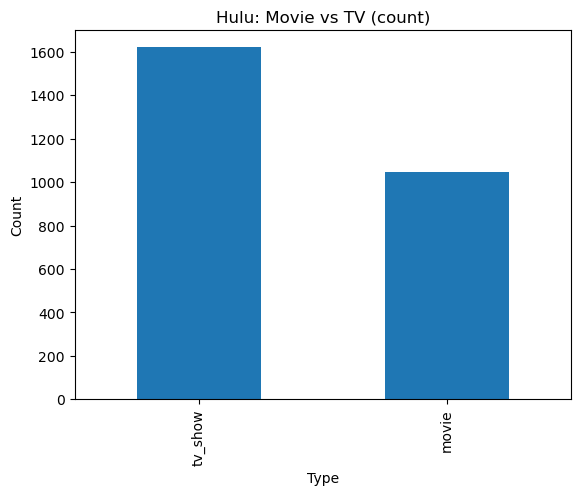

In [7]:
type_counts.plot(kind="bar")
plt.title(f"{PLATFORM}: Movie vs TV (count)")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

The bar graph indicates that Hulu provides more tv series more than movies

# 2. Genre mix (Top 10)

Genres are stored in text field. For movies, it is comma-seperated; for TV it can be a verbose level. We'll use a simple approach:

* split by comma (if present)
* trim whitespace
* count genres

In [8]:
def top_genres(df_in: pd.DataFrame, top_n: int = 10) -> pd.Series:
    g = df_in["Genre"].dropna().astype(str)
    #split on comma; if no comma, this still returns a single-item list
    exploded = g.str.split(",").explode().str.strip()
    exploded = exploded[exploded != ""]
    return exploded.value_counts().head(top_n)

genre_top = top_genres(platform_df, top_n = 10)
genre_top

Genre
reality television                984
drama film                        552
drama television series           150
comedy film                       136
action film                       108
documentary film                  107
thriller film                      96
comedy drama                       90
horror film                        90
LGBT-related television series     77
Name: count, dtype: int64

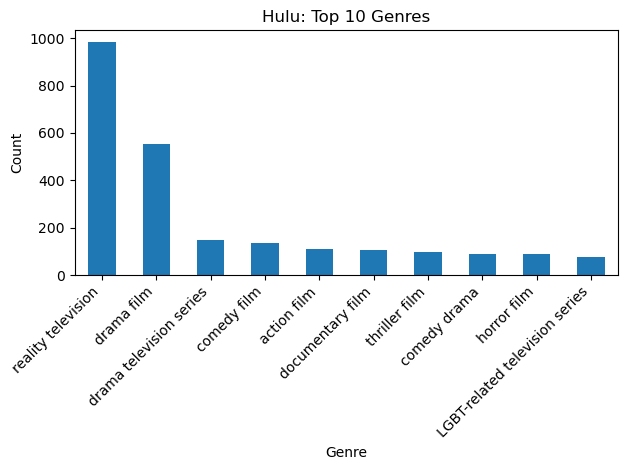

In [9]:
genre_top.plot(kind="bar")
plt.title(f"{PLATFORM}: Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The bar graph indicates that the top genres that is on Hulu are reality television and drama films.

# 3. Release Year Patterns

In [10]:
# Ensure Year is numeric
platform_df["Year"] = pd.to_numeric(platform_df["Year"], errors="coerce")

platform_df["Year"].describe()

count    2668.000000
mean     2011.005997
std        11.080608
min      1923.000000
25%      2009.000000
50%      2014.000000
75%      2018.000000
max      2021.000000
Name: Year, dtype: float64

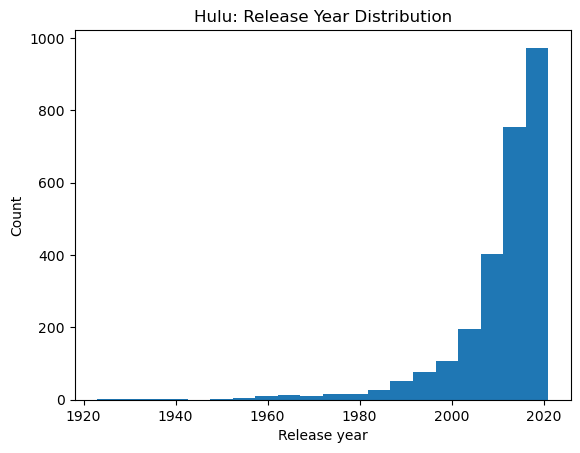

In [11]:
platform_df["Year"].dropna().plot(kind="hist", bins=20)
plt.title(f"{PLATFORM}: Release Year Distribution")
plt.xlabel("Release year")
plt.ylabel("Count")
plt.show()

The distribution is more skewed to the right, showing more current films and tv series more films and series from decades ago.

IMDb non-null: 2092


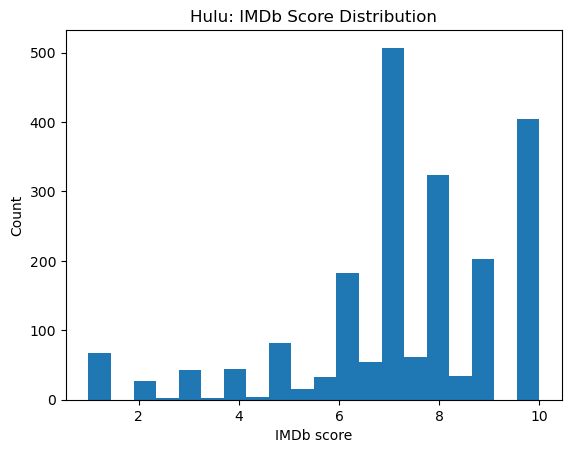

RottenTomatoes_Score non-null: 2668


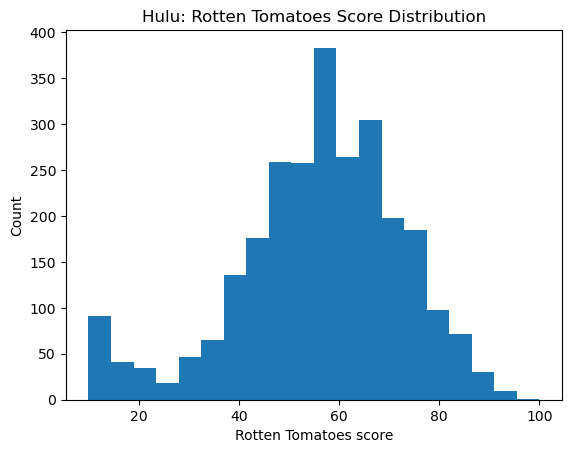

In [12]:
imdb = pd.to_numeric(platform_df["IMDb"], errors="coerce")
print("IMDb non-null:", imdb.notna().sum())

imdb.dropna().plot(kind="hist", bins=20)
plt.title(f"{PLATFORM}: IMDb Score Distribution")
plt.xlabel("IMDb score")
plt.ylabel("Count")
plt.show()

# Rotten Tomatoes distribution
rt = pd.to_numeric(platform_df["RottenTomatoes_Score"], errors="coerce")
print("RottenTomatoes_Score non-null:", rt.notna().sum())

rt.dropna().plot(kind="hist", bins=20)
plt.title(f"{PLATFORM}: Rotten Tomatoes Score Distribution")
plt.xlabel("Rotten Tomatoes score")
plt.ylabel("Count")
plt.show()

Type
movie      3695
tv_show    1971
Name: count, dtype: int64

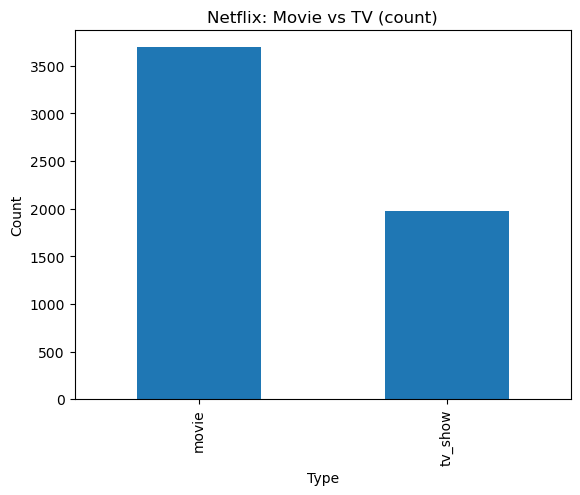

Genre
drama film                 1698
reality television         1027
Drama                       493
comedy film                 342
Comedy                      308
documentary film            243
Action                      204
drama television series     179
romantic comedy             159
Crime                       158
Name: count, dtype: int64

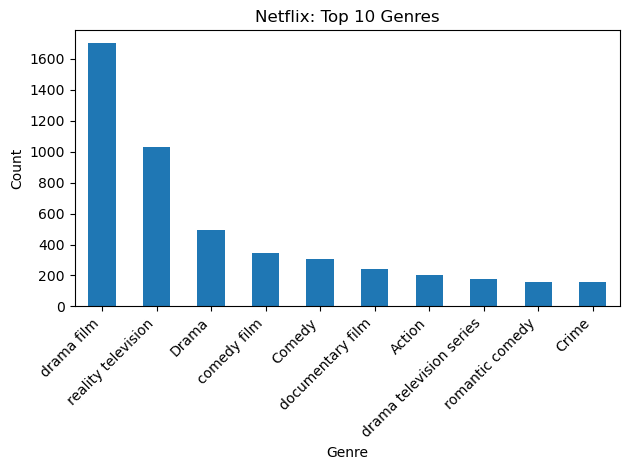

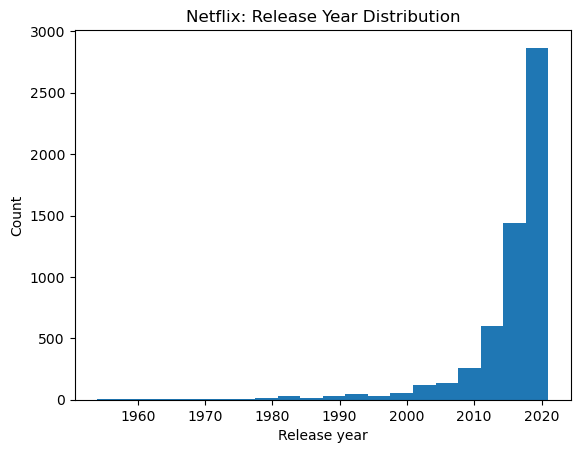

In [13]:
# Helper: one function to run the core analysis quickly
def analyze_platform(platform_name: str, top_n_genres: int = 10):
    sdf = df_long[df_long["platform"] == platform_name].copy()
    sdf["Year"] = pd.to_numeric(sdf["Year"], errors="coerce")

    # 1) Type mix
    type_counts = sdf["Type"].value_counts()
    display(type_counts)
    type_counts.plot(kind="bar")
    plt.title(f"{platform_name}: Movie vs TV (count)")
    plt.xlabel("Type")
    plt.ylabel("Count")
    plt.show()

    # 2) Genres
    genre_top = top_genres(sdf, top_n=top_n_genres)
    display(genre_top)
    genre_top.plot(kind="bar")
    plt.title(f"{platform_name}: Top {top_n_genres} Genres")
    plt.xlabel("Genre")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # 3) Year
    sdf["Year"].dropna().plot(kind="hist", bins=20)
    plt.title(f"{platform_name}: Release Year Distribution")
    plt.xlabel("Release year")
    plt.ylabel("Count")
    plt.show()

# Try:
analyze_platform("Netflix")